In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore') 


In [114]:
df = pd.read_csv('stud.csv')

In [115]:

df.head()



,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [116]:
df.shape

(1000, 8)

In [117]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [118]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [121]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [122]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


###Insights

->all means are very close to each other - between 66 and 68.05
->all std deviations are so close - between 14.6 and 15.19                                                          
->while there is a minimum score 0 for math,for writing minimum is much higher = 10 and for reading myet higher =17



In [123]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### Exploring Data


In [124]:
print("Categories in 'gender' variable:    ",end= " ")
print(df['gender'].unique())

Categories in 'gender' variable:     <StringArray>
['female', 'male']
Length: 2, dtype: str


In [125]:
df['race_ethnicity'].unique()

<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

In [126]:
df['parental_level_of_education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

In [127]:
df['lunch'].unique()

<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

In [128]:
df['test_preparation_course'].unique()

<StringArray>
['none', 'completed']
Length: 2, dtype: str

In [129]:
df['math_score'].unique()

array([ 72,  69,  90,  47,  76,  71,  88,  40,  64,  38,  58,  65,  78,
        50,  18,  46,  54,  66,  44,  74,  73,  67,  70,  62,  63,  56,
        97,  81,  75,  57,  55,  53,  59,  82,  77,  33,  52,   0,  79,
        39,  45,  60,  61,  41,  49,  30,  80,  42,  27,  43,  68,  85,
        98,  87,  51,  99,  84,  91,  83,  89,  22, 100,  96,  94,  48,
        35,  34,  86,  92,  37,  28,  24,  26,  95,  36,  29,  32,  93,
        19,  23,   8])

In [130]:
##define a numeeical and categorical column
numeric_features = [feature for feature in df.columns if df[feature].dtype!='str']
categorical_features = [feature for feature in df.columns if df[feature].dtype=='str']

print('We have {} numerical feature: {}'.format(len(numeric_features),numeric_features))

print('We have {} categorical feature: {}'.format(len(categorical_features),categorical_features))

We have 3 numerical feature: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical feature: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [131]:
## adding columns for total score and average
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [132]:
reading_full = df[df['reading_score']==100]['average'].count()
writing_full = df[df['writing_score']==100]['average'].count()
math_full = df[df['math_score']==100]['average'].count()


print(f'Number of student with full marks in math:{math_full}')
print(f'Number of student with full marks in reading:{reading_full}')
print(f'Number of student with full marks in writing:{writing_full}')

Number of student with full marks in math:7
Number of student with full marks in reading:17
Number of student with full marks in writing:14


In [133]:
reading_less_20 = df[df['reading_score']<=20]['average'].count()
writing_less_20 = df[df['writing_score']<=20]['average'].count()
math_less_20 = df[df['math_score']<=20]['average'].count()


print(f'Number of student with less than 20 marks in math:{math_less_20}')
print(f'Number of student with less than 20 marks in reading:{reading_less_20}')
print(f'Number of student with less than 20 marks in writing:{writing_less_20}')

Number of student with less than 20 marks in math:4
Number of student with less than 20 marks in reading:1
Number of student with less than 20 marks in writing:3


### Insights
-> from above values we get students have performed the worst maths
-> best performance is in reading section


4.Exploring Data (visualisation)

4.1 Visualize average score distribution to make some conclusion
  -> histogram
  -> kernal Distribution Function(KDE)
  

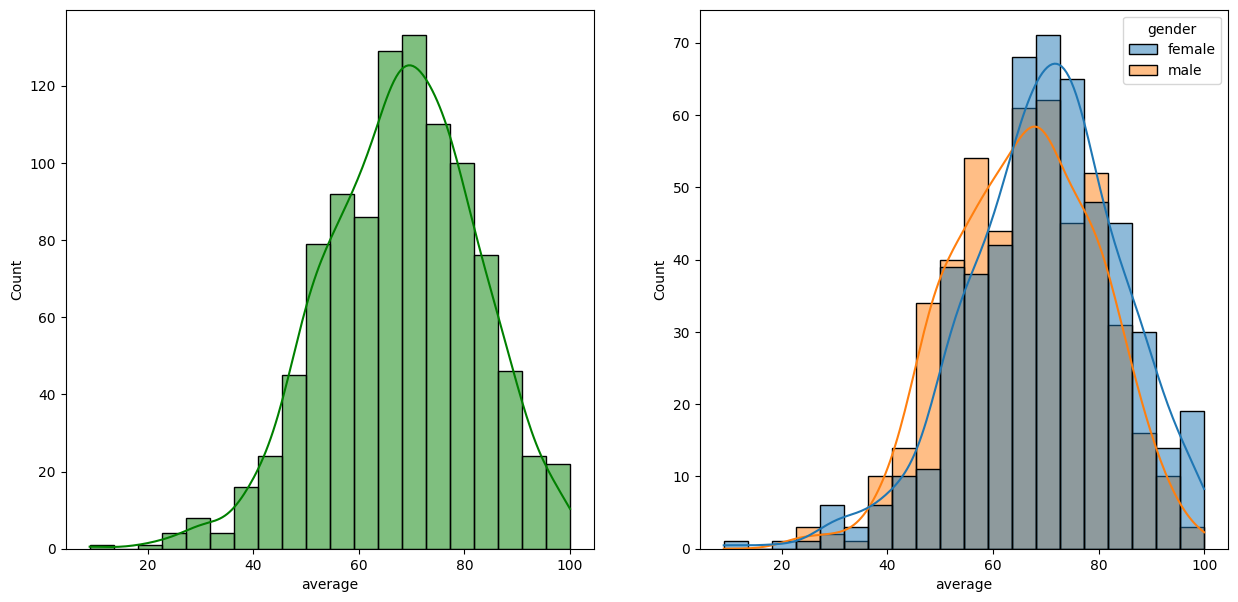

In [134]:
fig,axs =plt.subplots(1,2,figsize = (15,7))
plt.subplot(121)
sns.histplot(data =df,x='average' ,bins = 20 ,kde = True,color = 'g')
plt.subplot(122)
sns.histplot(data =df,x='average' ,bins = 20 ,kde = True,hue='gender')
plt.show()

##insights

->> female students perform better than male students


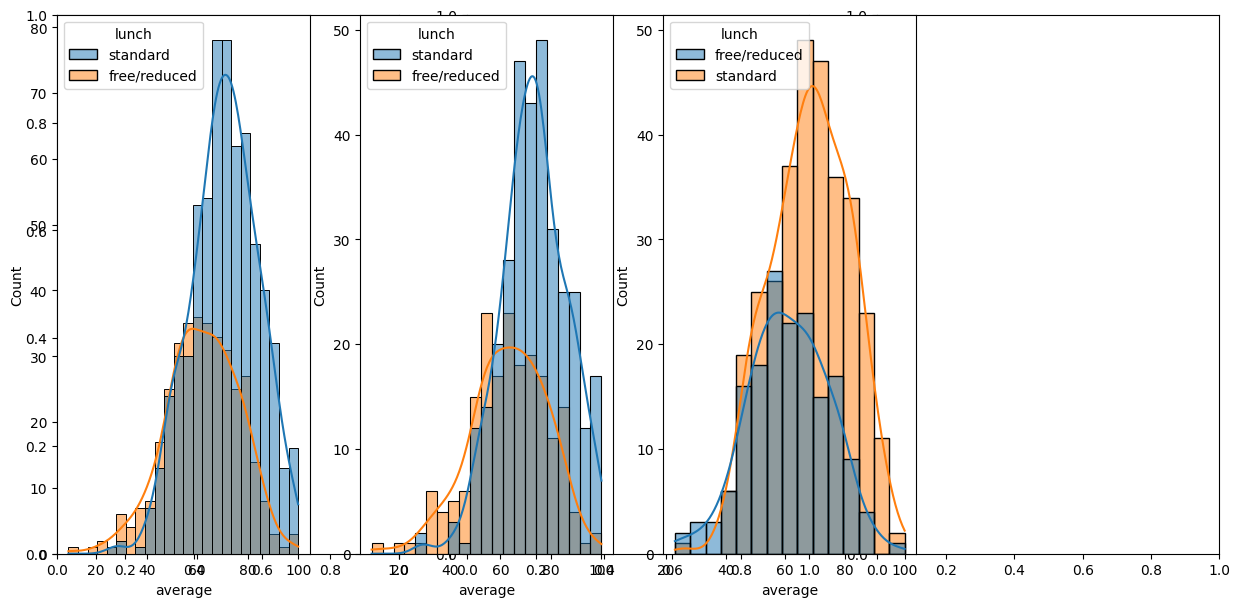

In [135]:
plt.subplots(1,3,figsize= (15,7))
plt.subplot(141)
sns.histplot(data =df,x='average',kde = True,hue = 'lunch')
plt.subplot(142)
sns.histplot(data =df[df.gender=='female'],x='average',kde = 'True',hue ='lunch')
plt.subplot(143)
sns.histplot(data =df[df.gender=='male'],x='average',kde = 'True',hue ='lunch')
plt.show()

### Insights
 
-> standard lunch helps perform well in exam
-> standard lunch helps perform in exam be it male or female


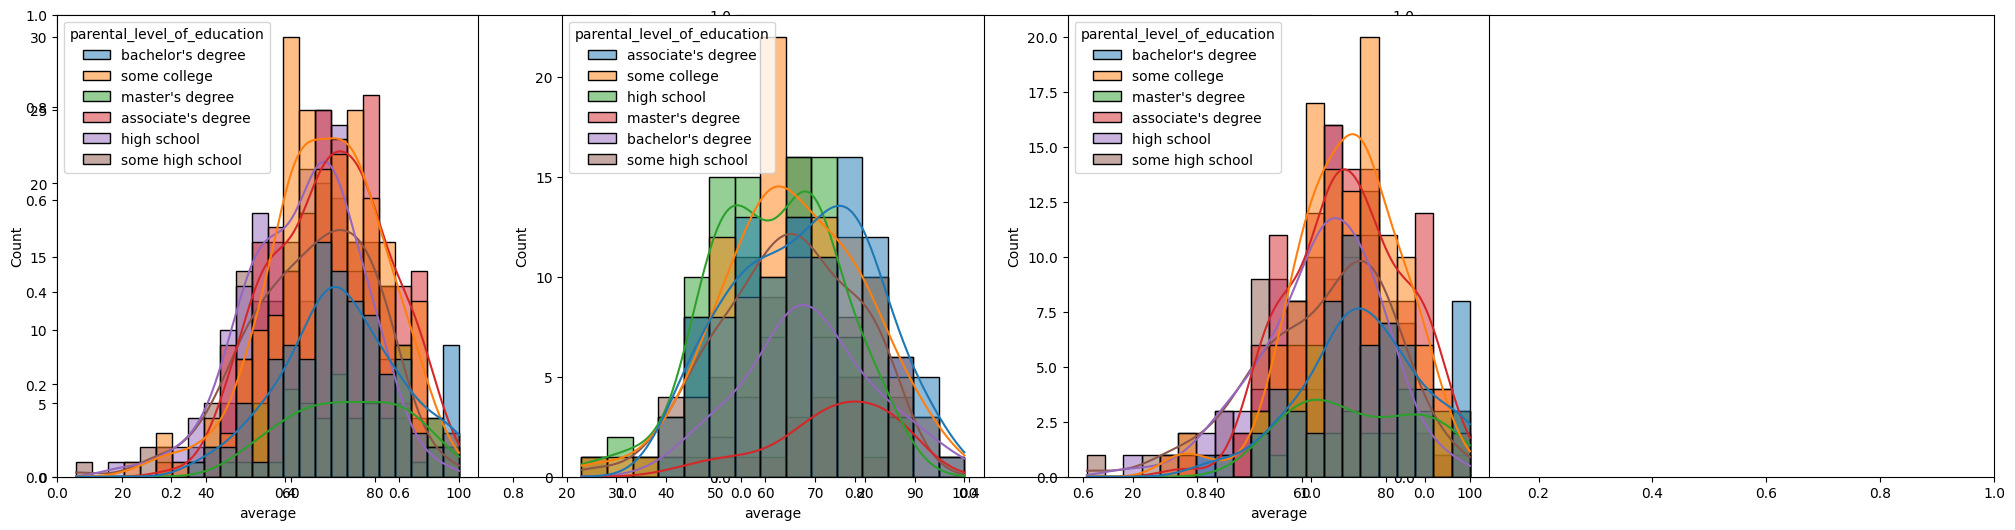

In [136]:

plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

###Insights
-> In general parent's education don't help student perform well in exam.
->2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
->3rd plot we can see there is no effect of parent's education on female students.

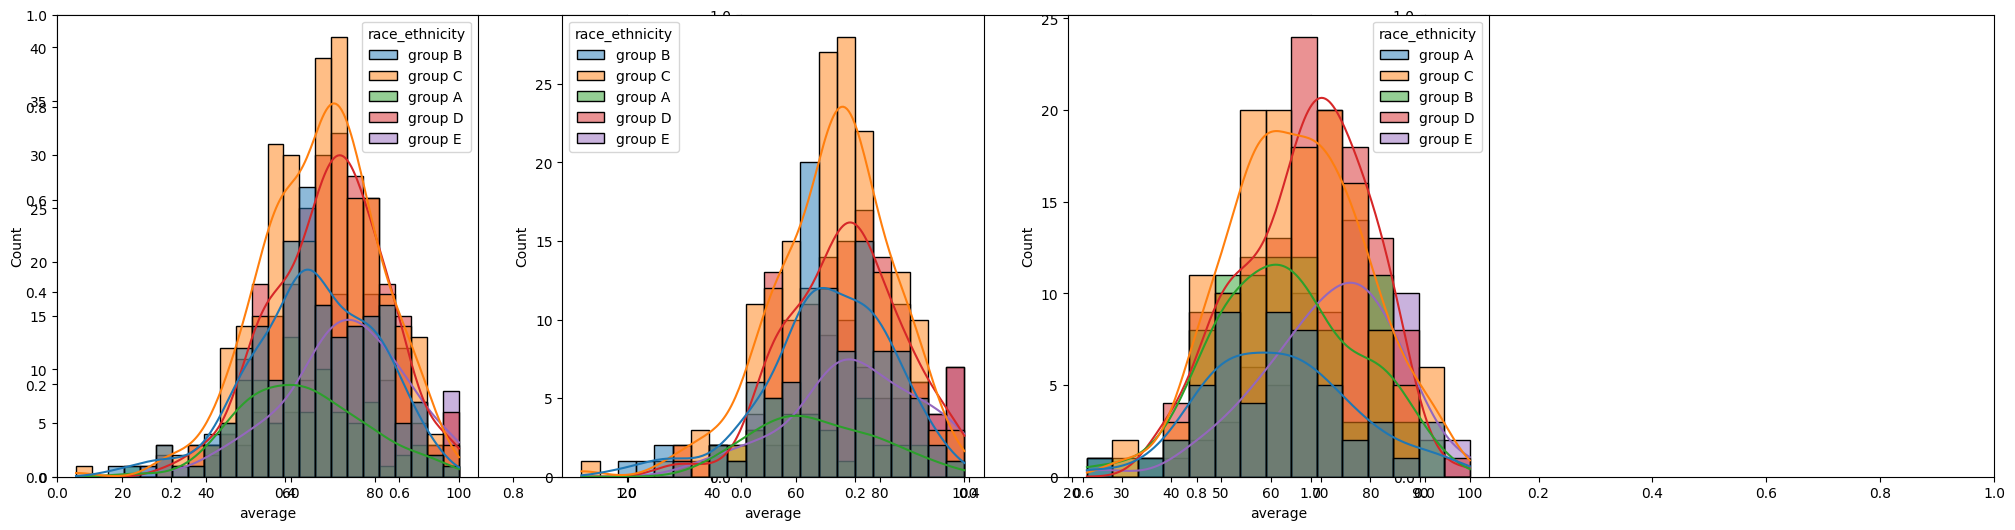

In [137]:

plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

###insights

Students from race/ethnicity groups A and B tend to have slightly lower average scores compared to other groups. 

This pattern appears consistently across both male and female students, suggesting that the trend is not strongly influenced by gender. However, there is significant overlap in score distributions, indicating that the difference is not very strong.

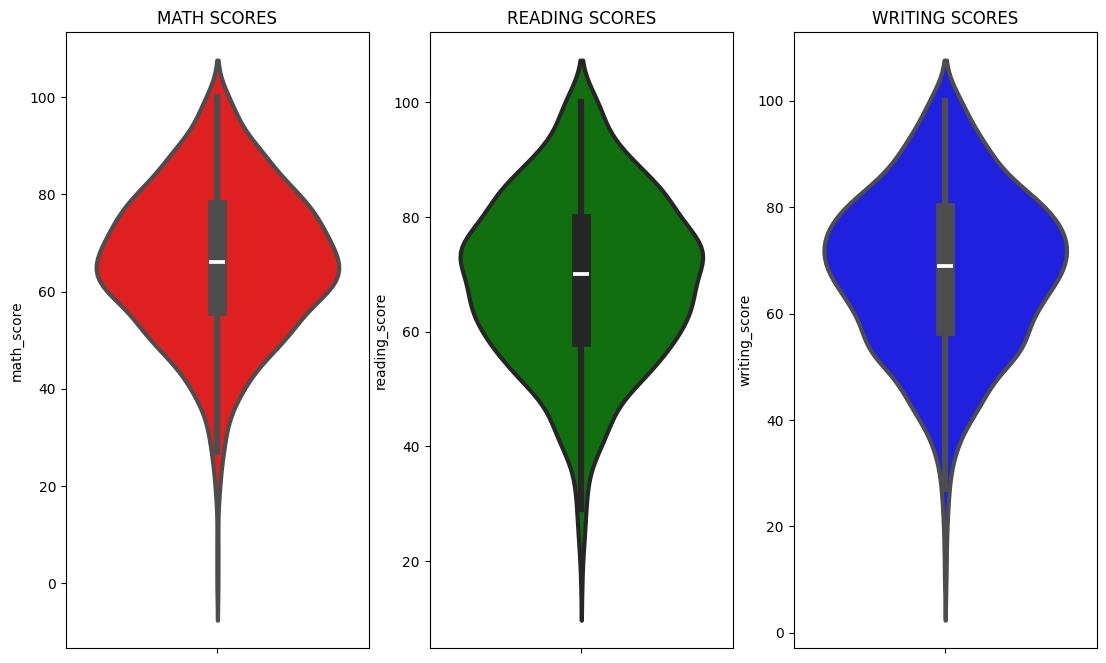

In [138]:
##maximum score of students in all three subjects
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

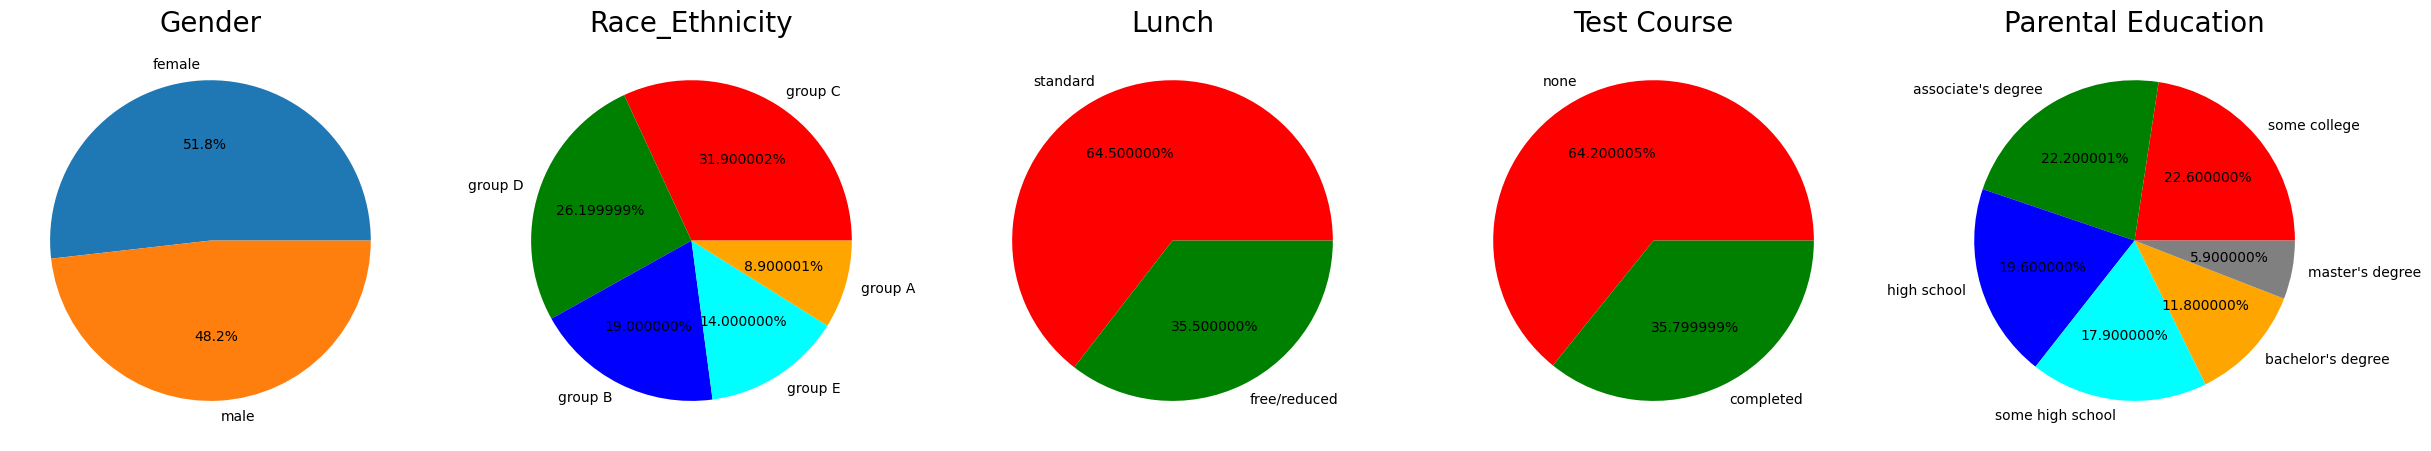

In [139]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)

size = df['gender'].value_counts()

plt.pie(size, labels=size.index, autopct='%1.1f%%')
color = ['red','green']
plt.title('Gender',fontsize = 20)
plt.axis('off')

plt.subplot(1,5,2)

size = df['race_ethnicity'].value_counts()
##labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = size.index,autopct = '%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
#plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
#labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = size.index,autopct = '%2f%%')
plt.title('Lunch', fontsize = 20)
#plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
#labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = size.index,autopct = '%2f%%')
plt.title('Test Course', fontsize = 20)
#plt.axis('off')

plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
#labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = size.index,autopct = '%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')

#plt.tight_layout()
#plt.grid()

plt.show()

<Axes: xlabel='gender', ylabel='count'>

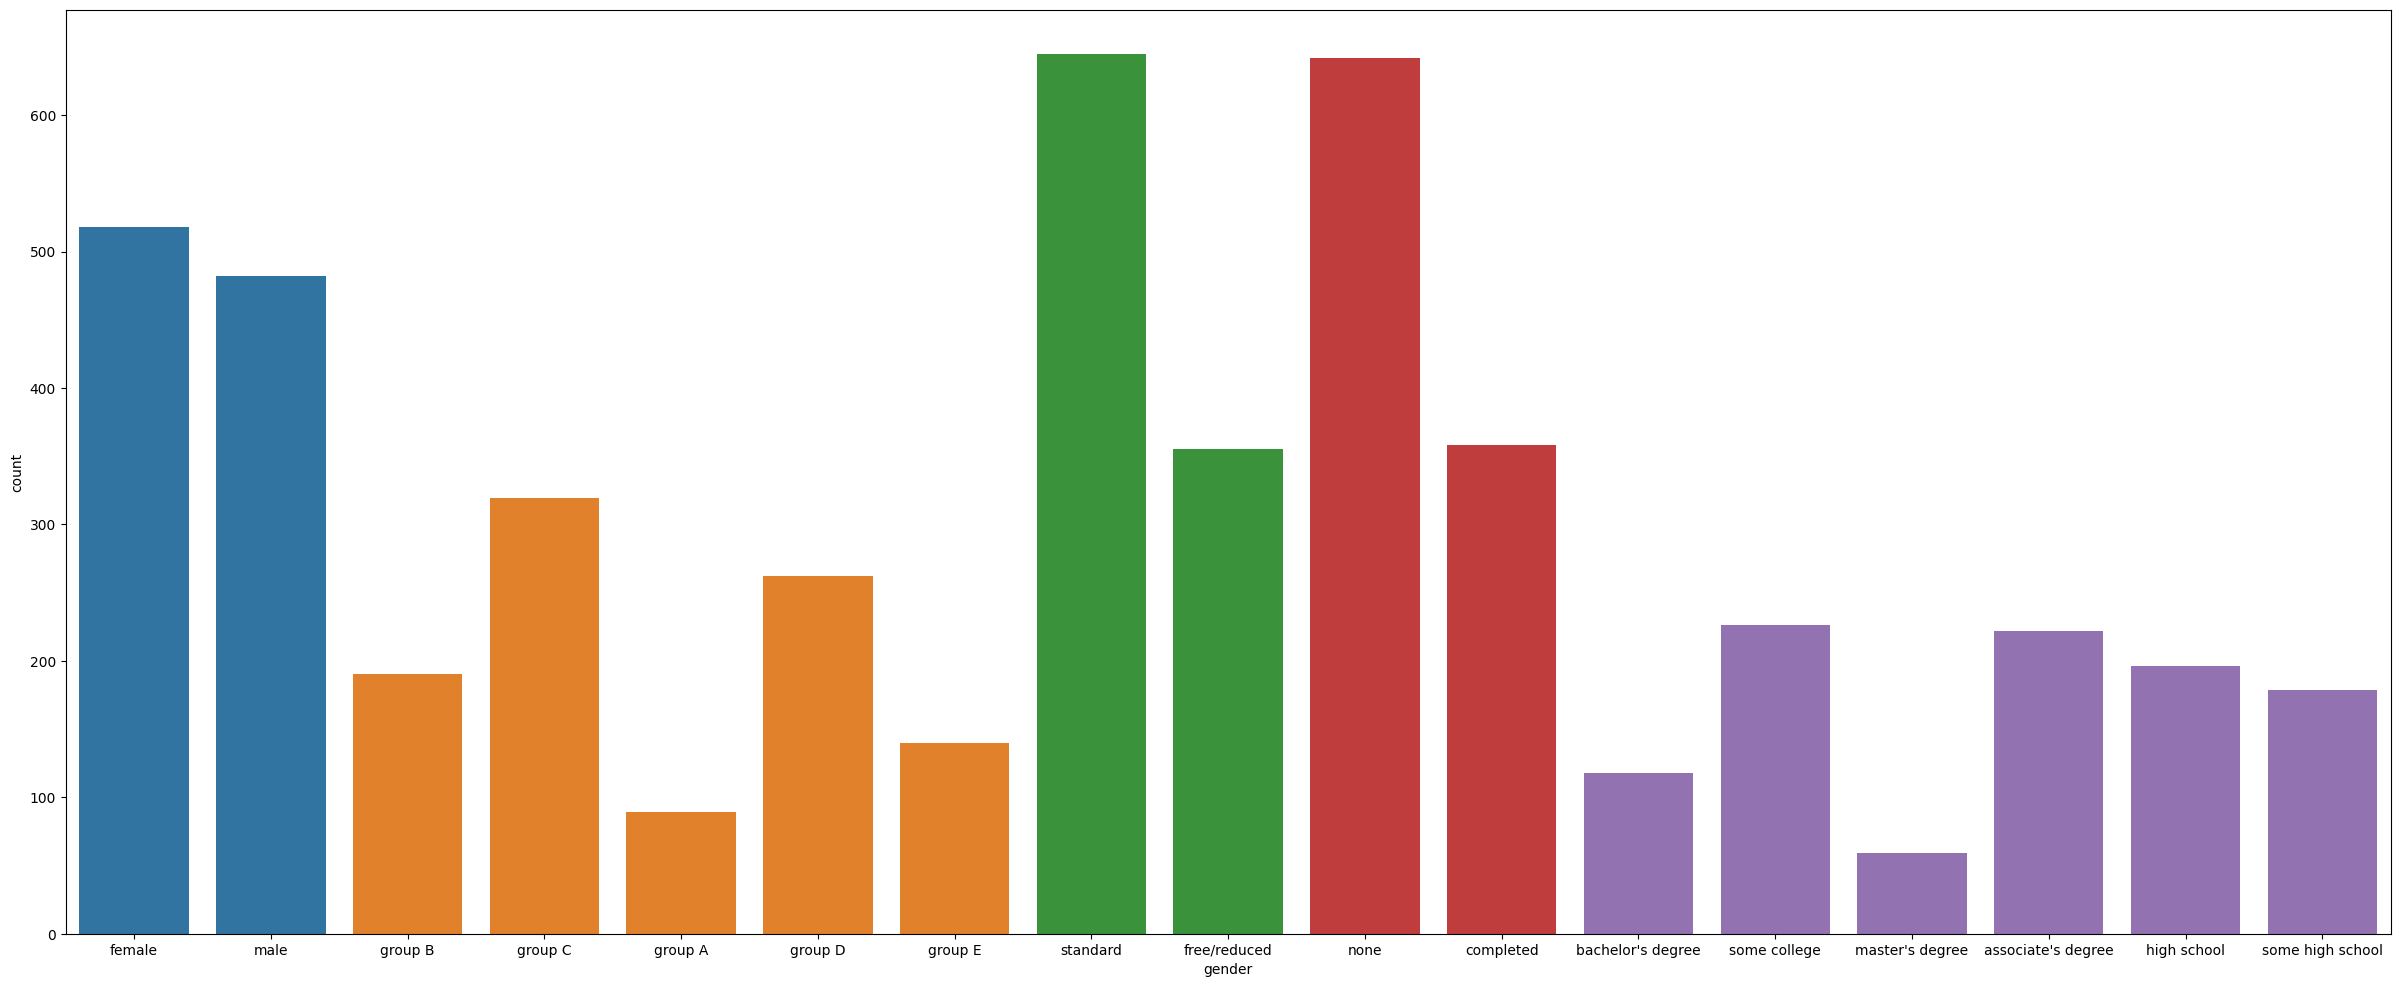

In [140]:
sns.countplot(x='gender', data=df)
sns.countplot(x='race_ethnicity', data=df)
sns.countplot(x='lunch', data=df)
sns.countplot(x='test_preparation_course', data=df)
sns.countplot(x='parental_level_of_education', data=df)

Insights

->Number of Male and Female students is almost equal

->Number students are greatest in Group C

->Number of students who have standard lunch are greater

->Number of students who have not enrolled in any test preparation course is greater

->Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### Univarite analysis(how is distribution of gender)


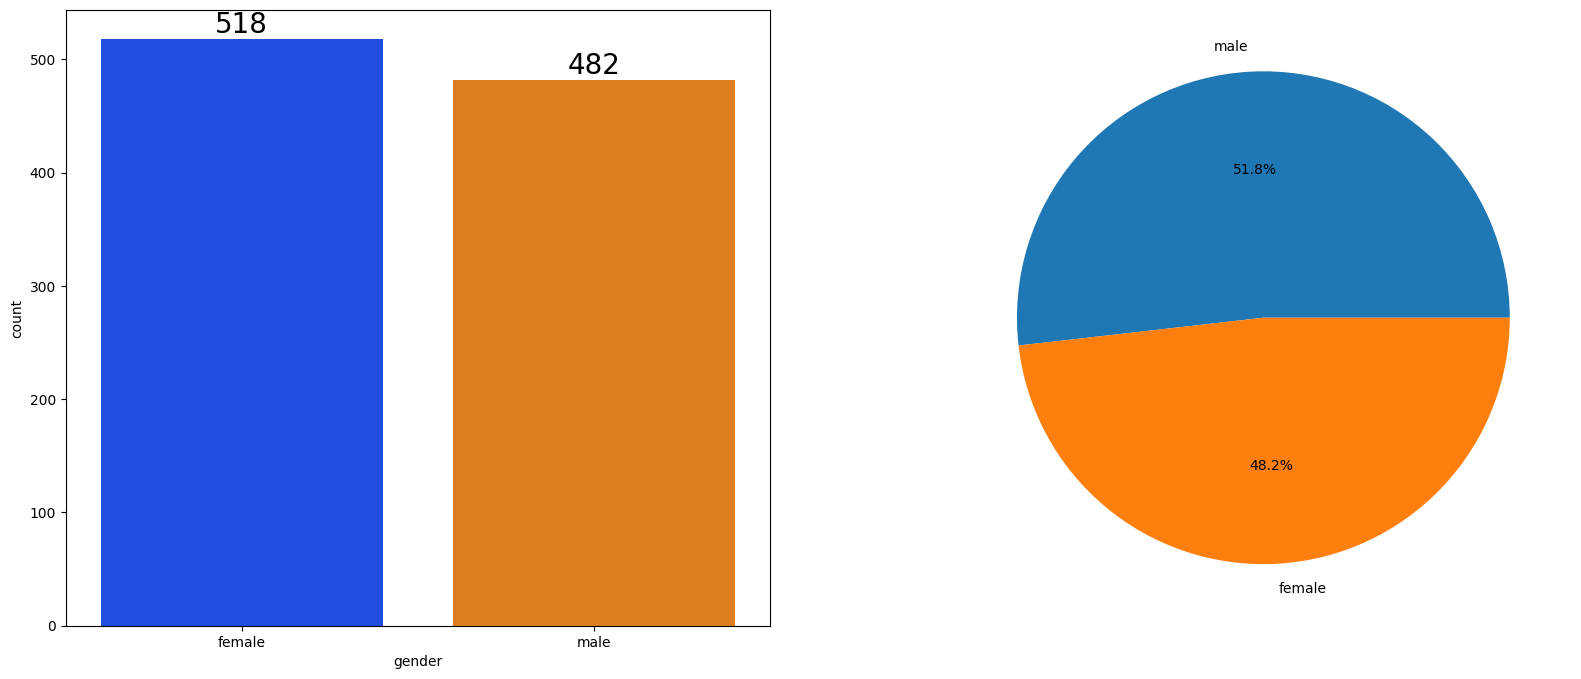

In [152]:
f,ax = plt.subplots(1,2,figsize =(20,8))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0])
for conatiner in ax[0].containers:
    ax[0].bar_label(conatiner,color ='black',size = 20)

plt.pie(x=df['gender'].value_counts(),labels=['male','female'],autopct ='%1.1f%%')
plt.show()

### Insights 
so these graphs are for checking imbalanced dataset
Gender has balanced data with female students 518 and male students are 482

### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [170]:

'''gender_group = df.groupby('gender')[['math_score','reading_score','writing_score']].mean()
gender_group

plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']

female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()
'''

'gender_group = df.groupby(\'gender\')[[\'math_score\',\'reading_score\',\'writing_score\']].mean()\ngender_group\n\nplt.figure(figsize=(10, 8))\n\nX = [\'Total Average\',\'Math Average\']\n\nfemale_scores = [gender_group[\'average\'][0], gender_group[\'math score\'][0]]\nmale_scores = [gender_group[\'average\'][1], gender_group[\'math score\'][1]]\n\nX_axis = np.arange(len(X))\n\nplt.bar(X_axis - 0.2, male_scores, 0.4, label = \'Male\')\nplt.bar(X_axis + 0.2, female_scores, 0.4, label = \'Female\')\n\nplt.xticks(X_axis, X)\nplt.ylabel("Marks")\nplt.title("Total average v/s Math average marks of both the genders", fontweight=\'bold\')\nplt.legend()\nplt.show()\n'

### Insights
On an average females have a better overall score than men.
whereas males have scored higher in Maths.

### UNIVARIATE ANALYSIS ( How is Group wise distribution of race_ethinicity ?)

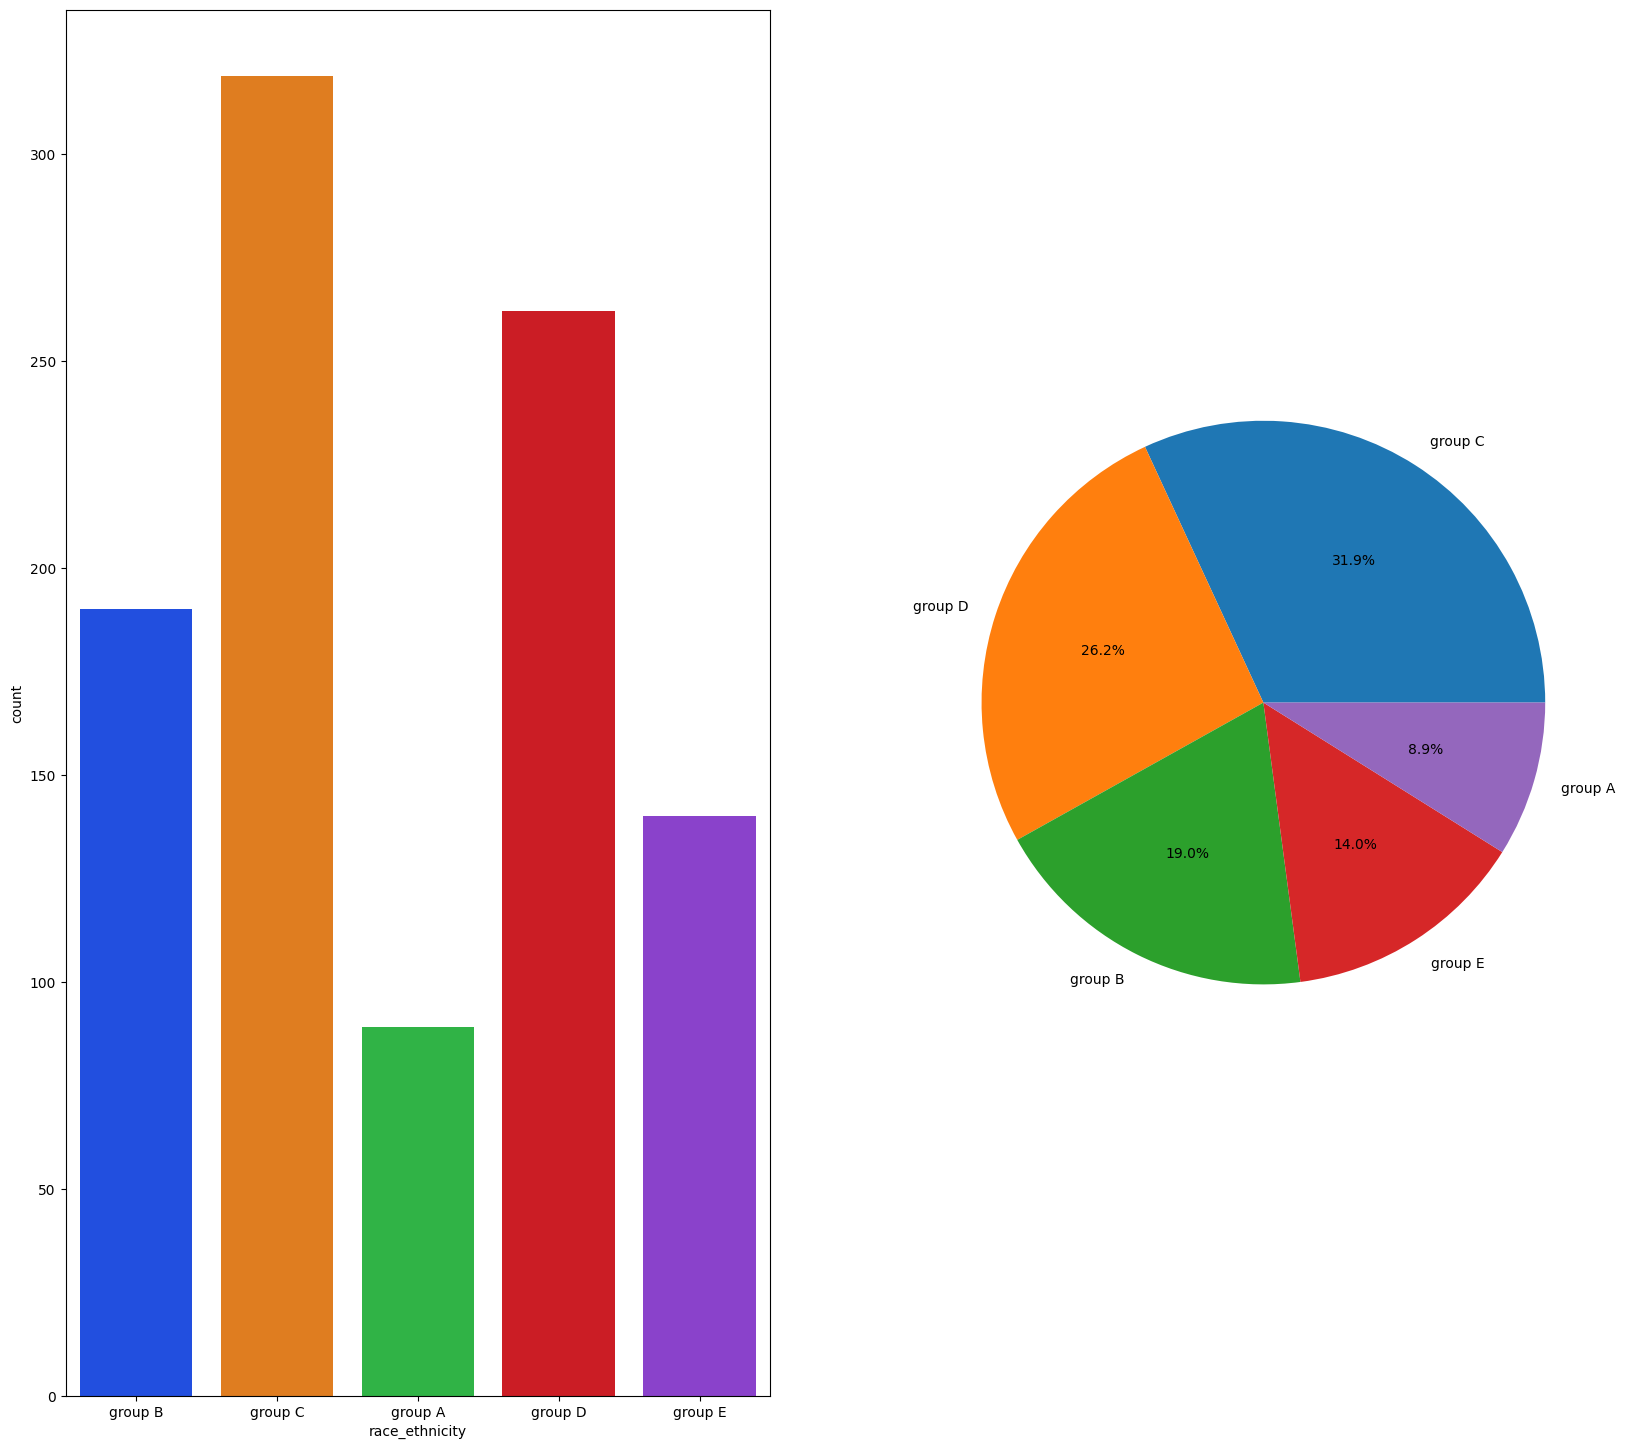

In [154]:
fig,ax = plt.subplots(1,2 ,figsize = (20,18))
sns.countplot(x=df['race_ethnicity'],data = df,palette='bright',ax = ax[0])
for container in ax[0].containers:
 ax[0].bar_label(conatiner,color ='black',size = 20)
size = df['race_ethnicity'].value_counts() 
plt.pie(x=size,labels=size.index,autopct = '%1.1f%%')
plt.show()

### Insights
Most of the student belonging from group C /group D.
Lowest number of students belong to groupA.

### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )


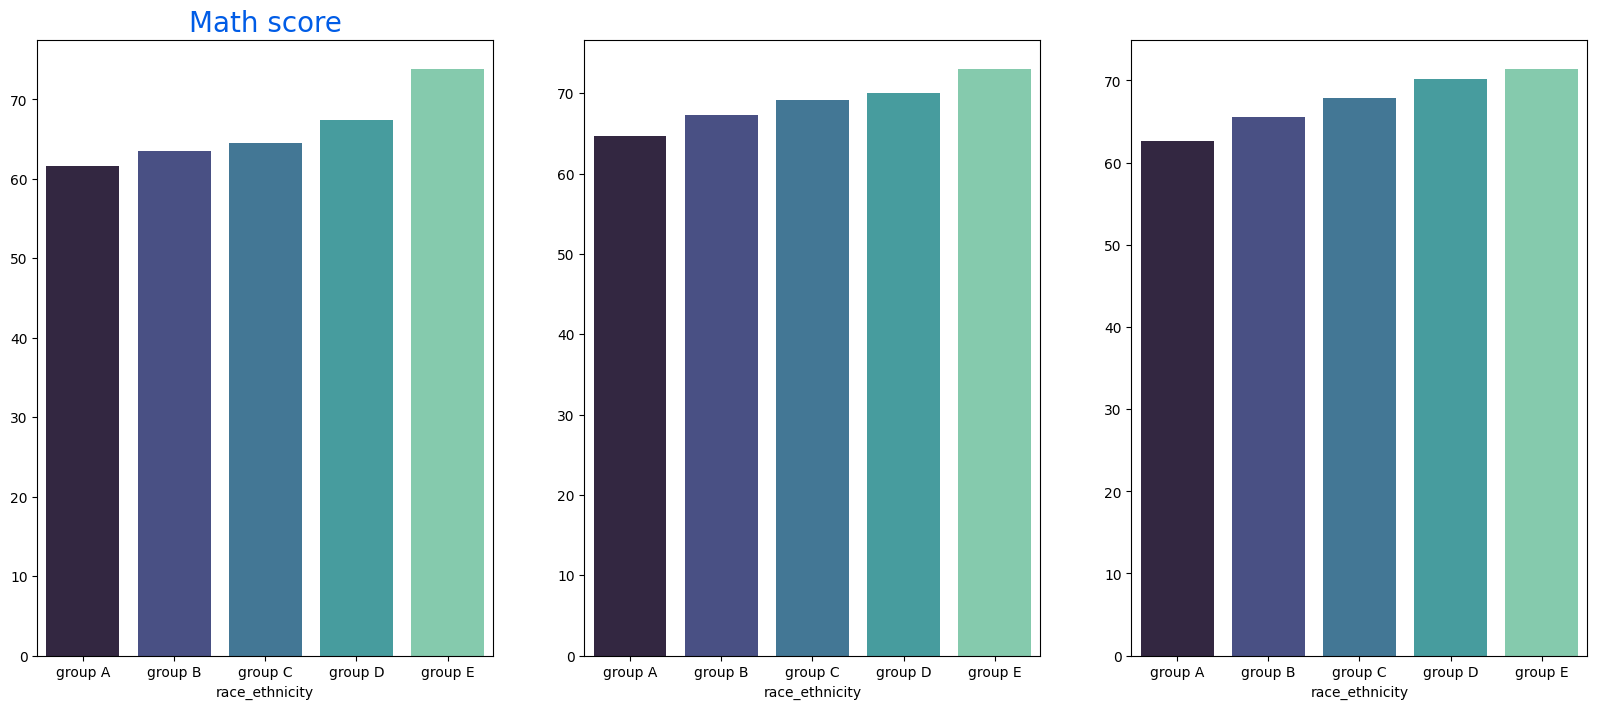

In [158]:
group_data2 = df.groupby('race_ethnicity')

f,ax = plt.subplots(1,3,figsize =(20,8))
sns.barplot(x=group_data2['math_score'].mean().index,
            y=group_data2['math_score'].mean().values,
            palette='mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(conatiner,color='black',size=15)

sns.barplot(x=group_data2['reading_score'].mean().index,
            y=group_data2['reading_score'].mean().values,
            palette='mako',ax=ax[1])

for container in ax[1].containers:
    ax[1].bar_label(conatiner,color='black',size=15)

sns.barplot(x=group_data2['writing_score'].mean().index,
            y=group_data2['writing_score'].mean().values,
            palette='mako',ax=ax[2]) 

for container in ax[2].containers:
    ax[2].bar_label(conatiner,color='black',size=15)  
            

### Insights
Group E students have scored the highest marks.
Group A students have scored the lowest marks.
Students from a lower Socioeconomic status have a lower avg in all course subjects

### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

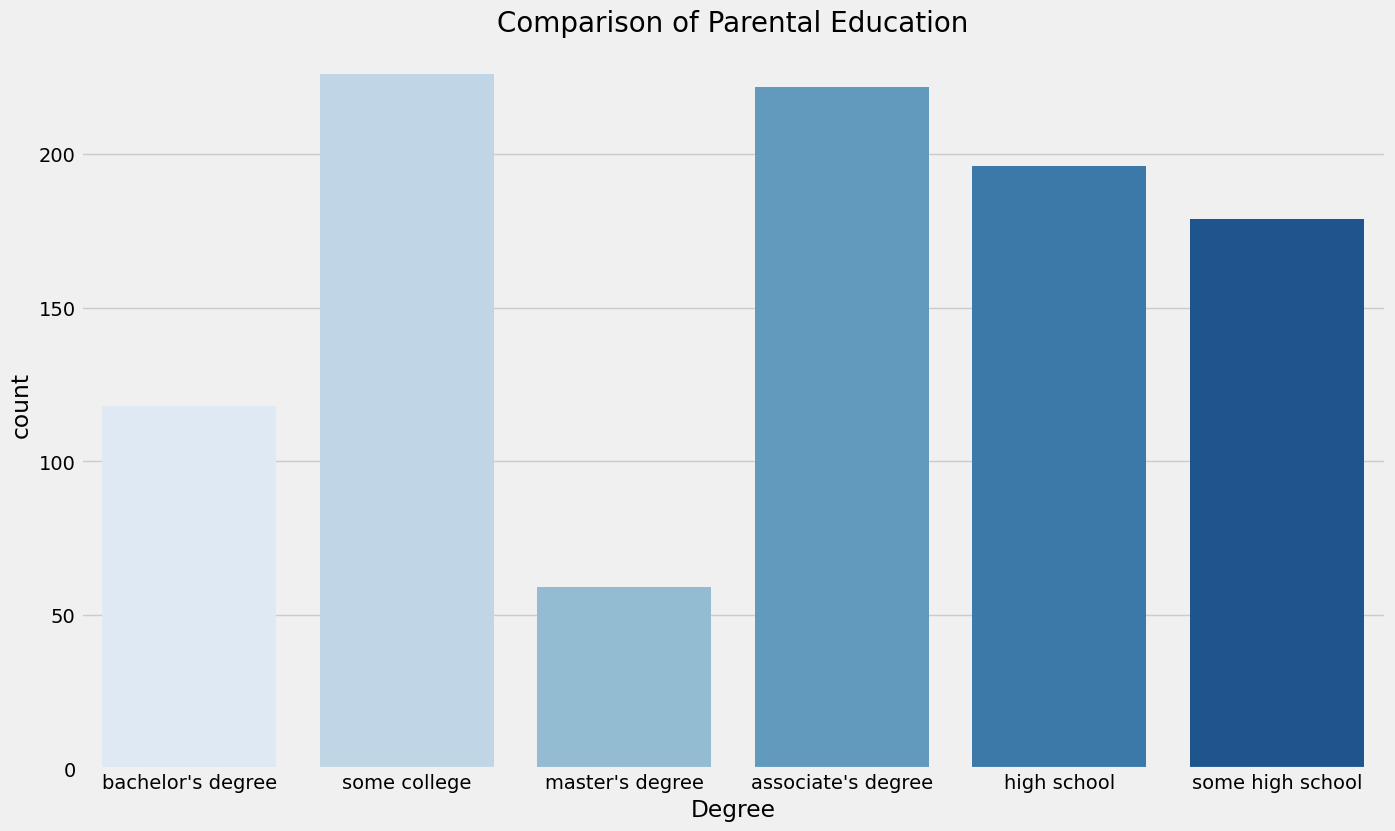

In [164]:
plt.rcParams['figure.figsize'] = (15, 9)
##plt.style.use('fivethirtyeight')
sns.countplot(x=df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

### Insights
Largest number of parents are from some college.


### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

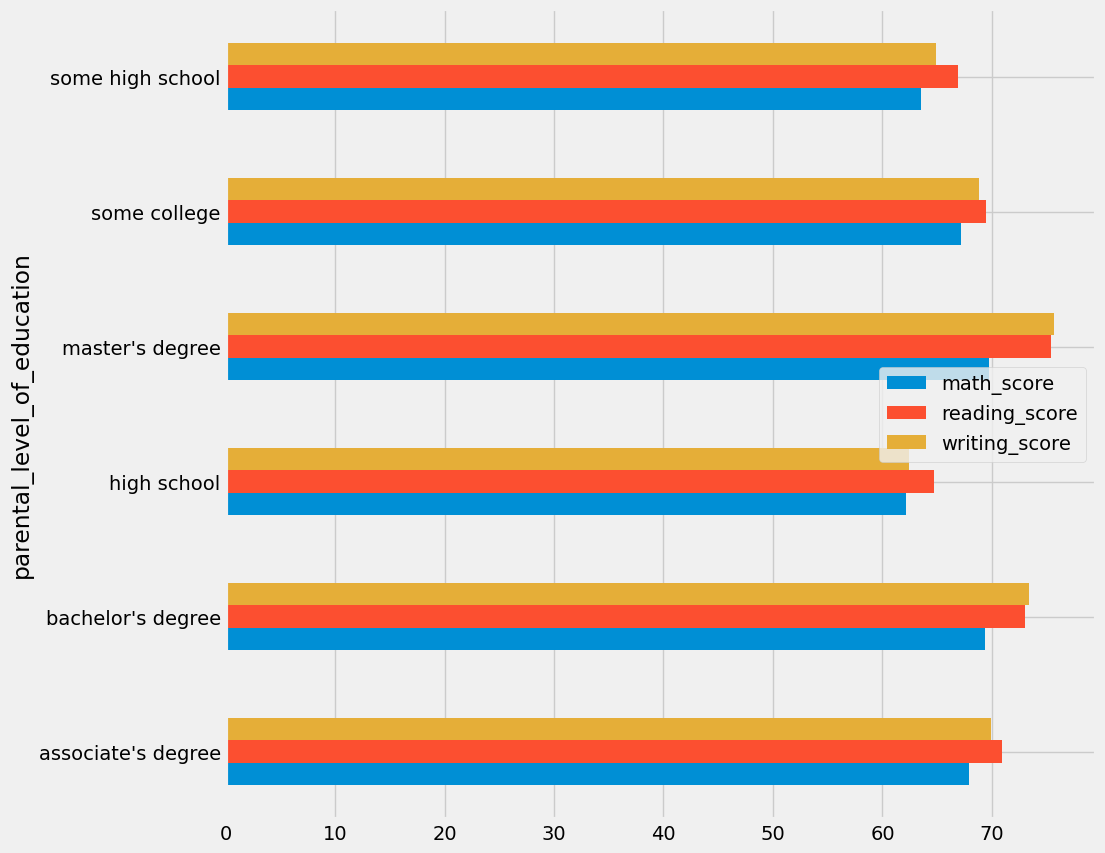

In [169]:
df.groupby('parental_level_of_education')[['math_score','reading_score','writing_score']].mean().plot(kind='barh', figsize=(10,10))

#plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


### Insights
The score of student whose parents possess master and bachelor level education are higher than others.

### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

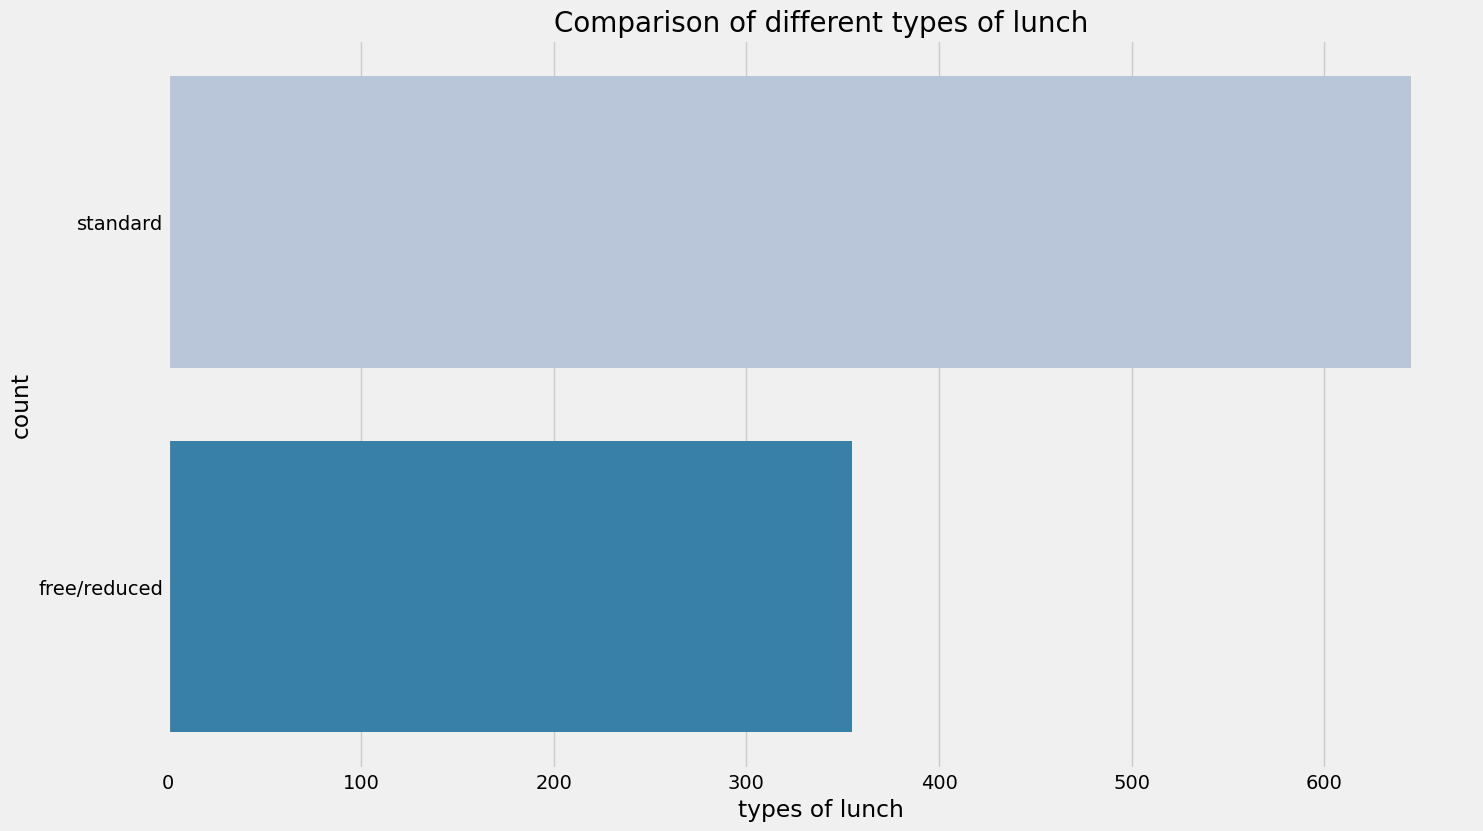

In [172]:
plt.rcParams['figure.figsize'] = (15, 9)
#plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

### Insights
Students being served Standard lunch was more than free lunch



### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

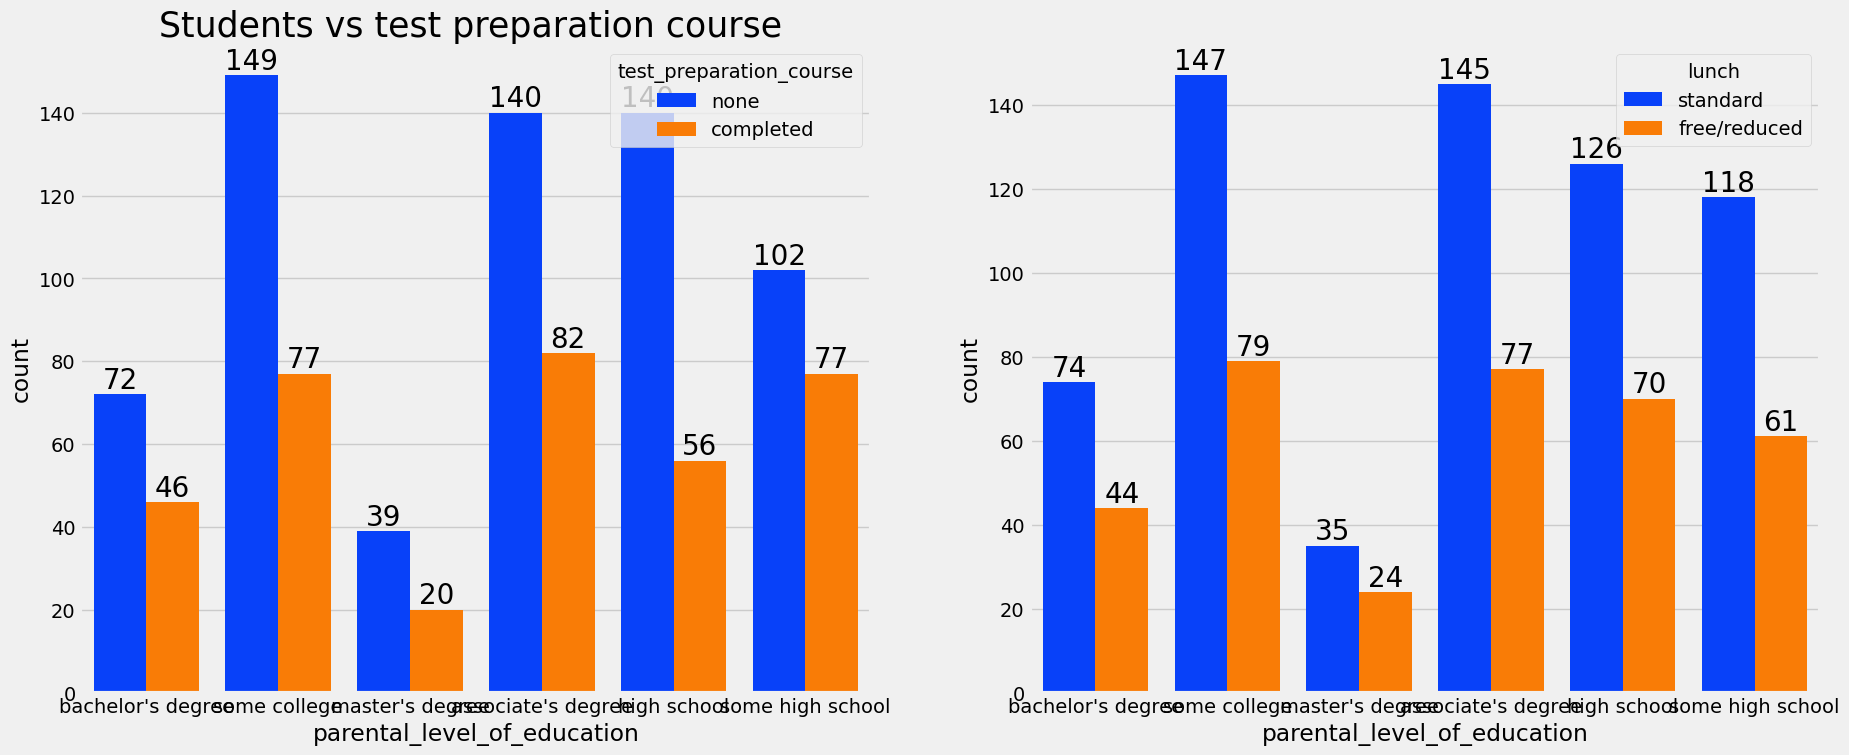

In [175]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:

    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)

### Insights
Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? 

<Axes: xlabel='lunch', ylabel='writing_score'>

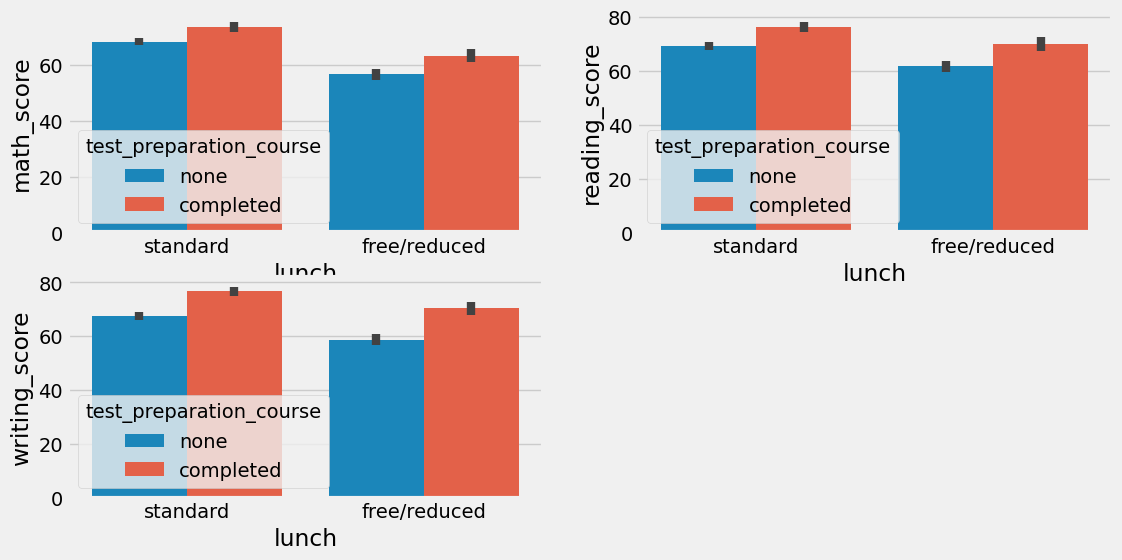

In [177]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

### Insights
Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

### CHECKING OUTLIERS




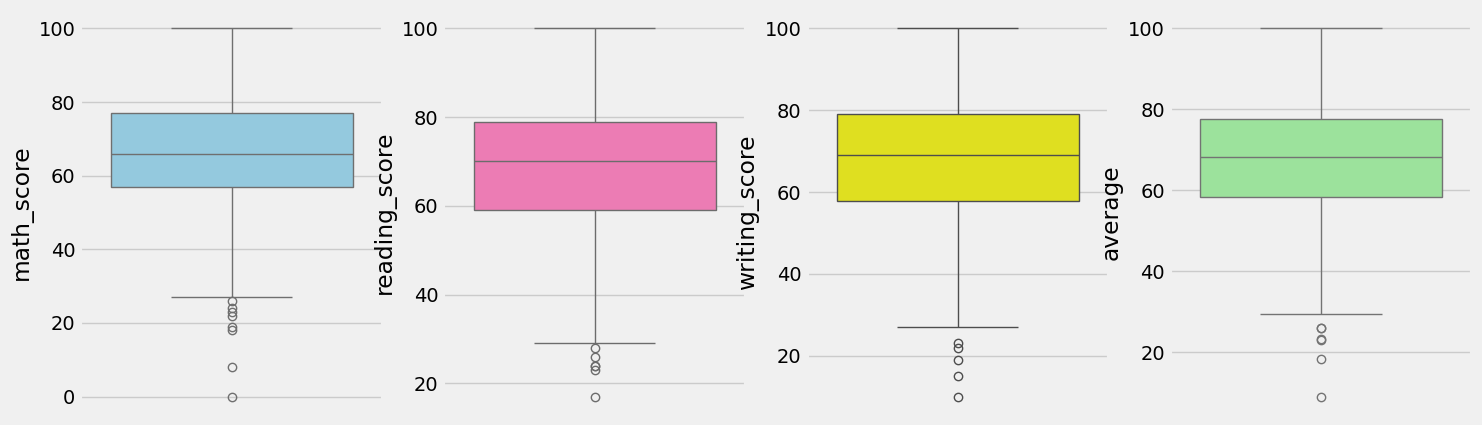

In [179]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

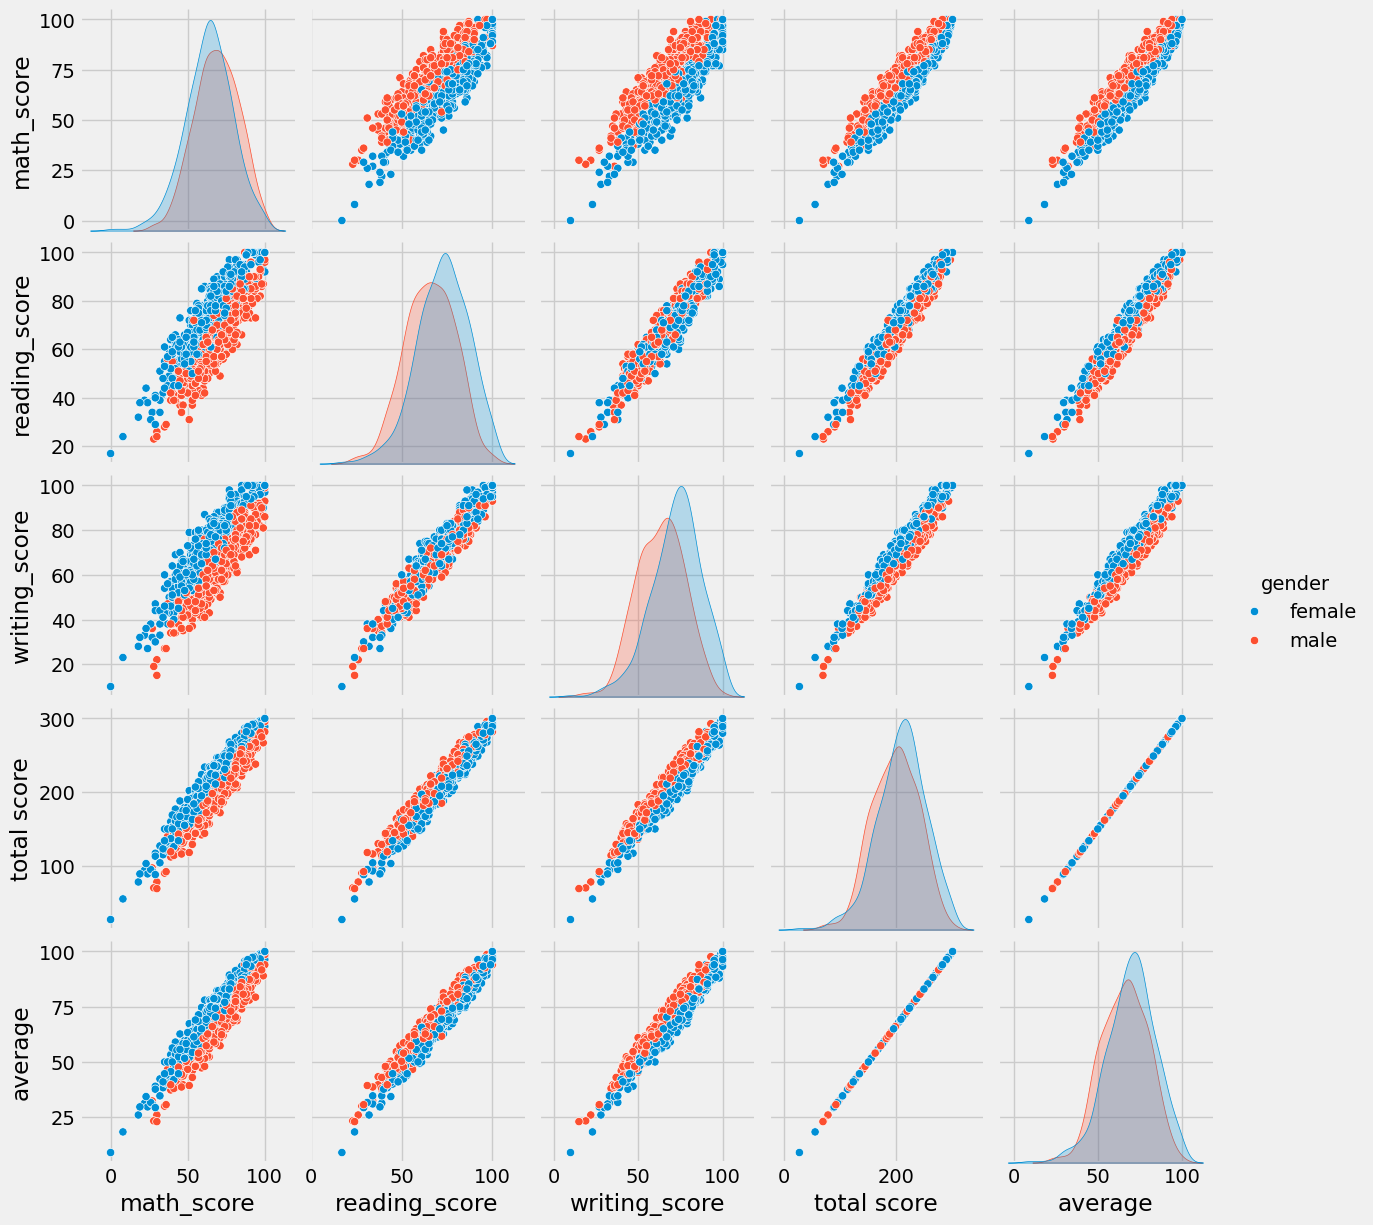

In [180]:
sns.pairplot(df,hue = 'gender')
plt.show()

### Insights
From the above plot it is clear that all the scores increase linearly with each other



### Conclusions
Student's Performance is related with lunch, race, parental level education

Females lead in pass percentage and also are top-scorers

Student's Performance is not much related with test preparation course

Finishing preparation course is benefitial.